[01:50:11] [alpha=1.000] bootstrap 1/200
[01:56:24] [alpha=1.000] bootstrap 21/200
[02:02:33] [alpha=1.000] bootstrap 41/200
[02:08:45] [alpha=1.000] bootstrap 61/200
[02:14:55] [alpha=1.000] bootstrap 81/200
[02:21:00] [alpha=1.000] bootstrap 101/200
[02:27:07] [alpha=1.000] bootstrap 121/200
[02:33:19] [alpha=1.000] bootstrap 141/200
[02:39:19] [alpha=1.000] bootstrap 161/200
[02:45:30] [alpha=1.000] bootstrap 181/200
[02:51:19] [alpha=1.000] bootstrap 200/200
[02:51:38] [RESULT alpha=1.000] mean_cov=0.9378, min_cov=0.0100, mean_bw=0.0317


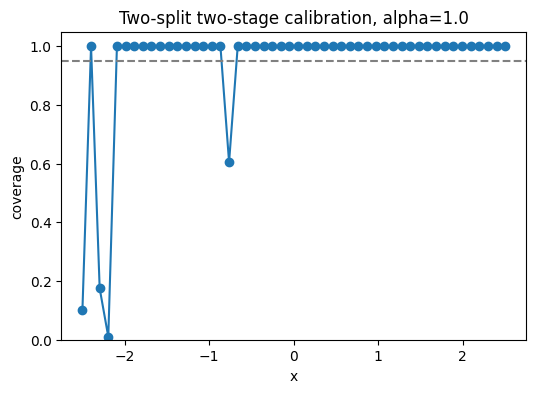

In [1]:
# Cell 1: imports

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.__version__, gpytorch.__version__

# Cell 2: helpers and true function

def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)

def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context():
    """Optional CIQ settings; default我们会关掉 use_ciq，所以可以不启用。"""
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# stratified points (LHS-like)
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, device=device)
    return x[perm].unsqueeze(-1)

# Cell 3: config and model

@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000   # 可以先改小点，比如 1000 做 smoke test
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping for Stage-1
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Cell 4: param helpers, Stage-1 and Stage-2

def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """只选 variational covariance 相关参数，不动 mean/kernel/likelihood."""
    trainables = []
    vs = getattr(model, "variational_strategy", None)
    vdist_mod = None
    if vs is not None:
        vdist_mod = getattr(vs, "_variational_distribution", None)
        if vdist_mod is None:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p)
            else:
                p.requires_grad_(False)
    if not trainables:
        for n, p in model.named_parameters():
            low = n.lower()
            if (
                "variational_strategy" in low
                and any(
                    k in low
                    for k in [
                        "chol_variational_covar",
                        "raw_covar",
                        "chol_factor",
                        "covar_factor",
                        "variational_stddev",
                        "raw_var",
                        "qchol",
                        "q_scale_tril",
                    ]
                )
                and "mean" not in low
            ):
                p.requires_grad_(True); trainables.append(p)
    return trainables

def stage1_train(model, likelihood, x_train_std, y_train,
                 lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta):
    """Stage-1: alpha=1, 训 mean + kernel (+ likelihood)."""
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=1.0
    )

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam(
        [
            {"params": model.variational_parameters()},
            {"params": model.hyperparameters()},
            {"params": likelihood.parameters()},
        ],
        lr=lr,
    )

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train(); likelihood.train()
    best_loss, best_epoch = float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1
            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return best_epoch, best_loss

def stage2_train_cov_only(model, likelihood, x_train_std, y_train,
                          beta, lr, epochs, jitter, batch_size):
    """Stage-2: 固定 mean/kernel/likelihood，只训 variational covariance."""
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found for Stage-2."

    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=beta
    )
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train(); likelihood.train()
    best_loss, best_epoch = float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return best_epoch, best_loss


# Cell 5: two-split, two-stage calibration for one alpha

def calibrate_alpha_once(alpha=1.0, B=200, seed=2025, verbose=True):
    """
    完整 two-split, two-stage calibration（单个 alpha）：
      - 全局 symmetric std；Z/X* 固定（与 coverage 脚本一致）
      - Split-1: Stage-1(α=1) + Stage-2(β=1/α, cov-only) => mu_truth(x*)
      - Split-2: Stage-1(α=1) anchor; B 个 bootstrap，每次 Stage-2(β=1/α, cov-only)
      - 用 Split-2 的 CI 覆盖 mu_truth 作 coverage
    返回:
      - dict: mean_coverage, min_coverage, mean_bandwidth, coverage_curve, x_grid
    """
    beta = 1.0 / alpha
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # global seeds
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # === 1) 全局数据 + 对称归一化 + Z / X* ===
    gen = torch.Generator(device=device).manual_seed(cfg.seed)

    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train,
        low=cfg.train_low,
        high=cfg.train_high,
        generator=gen,
        device=device,
        dtype=torch.get_default_dtype(),
    )
    x_test_raw = torch.linspace(
        cfg.test_low,
        cfg.test_high,
        cfg.n_test,
        device=device,
        dtype=torch.get_default_dtype(),
    ).unsqueeze(1)

    mid = torch.tensor(
        [(cfg.train_low + cfg.train_high) / 2.0],
        device=device,
        dtype=torch.get_default_dtype(),
    )
    half = torch.tensor(
        [(cfg.train_high - cfg.train_low) / 2.0],
        device=device,
        dtype=torch.get_default_dtype(),
    ).clamp_min(1e-12)

    def to_std(x_raw): return (x_raw - mid) / half

    x_train_std_full = to_std(x_train_raw)
    x_test_std = to_std(x_test_raw)

    Z_raw = torch.linspace(
        cfg.train_low,
        cfg.train_high,
        cfg.inducing_points,
        device=device,
        dtype=torch.get_default_dtype(),
    ).unsqueeze(1)
    Z_std = to_std(Z_raw)

    y_train_full = f0(x_train_raw).squeeze(-1)

    # === 2) equal split: 250 / 250 ===
    perm = torch.randperm(cfg.n_train, device=device)
    idx1 = perm[: cfg.n_train // 2]
    idx2 = perm[cfg.n_train // 2 : cfg.n_train]

    x1, y1 = x_train_std_full[idx1], y_train_full[idx1]
    x2, y2 = x_train_std_full[idx2], y_train_full[idx2]

    # === 3) Split-1: full two-stage => mu_truth ===
    model_s1 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
    lik_s1 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
    with torch.no_grad():
        model_s1.covar_module.base_kernel.lengthscale.fill_(1.0)
        model_s1.covar_module.outputscale.fill_(1.0)
        lik_s1.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
    lik_s1.noise_covar.raw_noise.requires_grad_(False)

    with (ciq_context() if cfg.use_ciq else ExitStack()):
        _be1_s1, _bl1_s1 = stage1_train(
            model_s1, lik_s1,
            x_train_std=x1, y_train=y1,
            lr=cfg.lr_adam_stage1,
            epochs=cfg.stage1_epochs,
            jitter=cfg.jitter,
            batch_size=min(cfg.batch_size, x1.size(0)),
            early_stop_patience=cfg.early_stop_patience,
            early_stop_min_delta=cfg.early_stop_min_delta,
        )

    with (ciq_context() if cfg.use_ciq else ExitStack()):
        _be1_s2, _bl1_s2 = stage2_train_cov_only(
            model_s1, lik_s1,
            x_train_std=x1, y_train=y1,
            beta=beta,
            lr=cfg.lr_adam_stage2,
            epochs=cfg.stage2_epochs,
            jitter=cfg.jitter,
            batch_size=min(cfg.batch_size, x1.size(0)),
        )

    with torch.no_grad():
        mu_truth = model_s1(x_test_std).mean.detach()

    # === 4) Split-2: Stage-1 anchor ===
    model_anchor = SVGPModel(Z_std.clone().contiguous()).to(device=device)
    lik_anchor = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
    with torch.no_grad():
        model_anchor.covar_module.base_kernel.lengthscale.fill_(1.0)
        model_anchor.covar_module.outputscale.fill_(1.0)
        lik_anchor.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
    lik_anchor.noise_covar.raw_noise.requires_grad_(False)

    with (ciq_context() if cfg.use_ciq else ExitStack()):
        _be2_s1, _bl2_s1 = stage1_train(
            model_anchor, lik_anchor,
            x_train_std=x2, y_train=y2,
            lr=cfg.lr_adam_stage1,
            epochs=cfg.stage1_epochs,
            jitter=cfg.jitter,
            batch_size=min(cfg.batch_size, x2.size(0)),
            early_stop_patience=cfg.early_stop_patience,
            early_stop_min_delta=cfg.early_stop_min_delta,
        )

    s2_model_sd = clone_state_dict(model_anchor.state_dict())
    s2_lik_sd   = clone_state_dict(lik_anchor.state_dict())

    # === 5) Bootstrap on Split-2 with Stage-2 (cov-only) ===
    J = x_test_std.size(0)
    indicators = np.zeros((B, J), dtype=np.float64)
    avg_bandwidth = np.zeros(B, dtype=np.float64)

    idx_all = torch.arange(x2.size(0), device=device)
    for b in range(B):
        if verbose and (b % 20 == 0 or b == B-1):
            log(f"[alpha={alpha:.3f}] bootstrap {b+1}/{B}")

        boot_idx = idx_all[torch.randint(
            low=0, high=x2.size(0),
            size=(x2.size(0),),
            device=device,
        )]
        xb, yb = x2[boot_idx], y2[boot_idx]

        model_b = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        lik_b   = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
        model_b.load_state_dict(s2_model_sd)
        lik_b.load_state_dict(s2_lik_sd)

        with (ciq_context() if cfg.use_ciq else ExitStack()):
            _be_s2, _bl_s2 = stage2_train_cov_only(
                model_b, lik_b,
                x_train_std=xb, y_train=yb,
                beta=beta,
                lr=cfg.lr_adam_stage2,
                epochs=cfg.stage2_epochs,
                jitter=cfg.jitter,
                batch_size=min(cfg.batch_size, xb.size(0)),
            )

        with torch.no_grad():
            pf = model_b(x_test_std)
            mu_b  = pf.mean
            std_b = pf.variance.sqrt().clamp_min(1e-12)
            lower, upper = mu_b - 1.96 * std_b, mu_b + 1.96 * std_b
            cover = ((mu_truth >= lower) & (mu_truth <= upper)).to(torch.float64)
            indicators[b, :] = cover.cpu().numpy()
            avg_bandwidth[b] = float((1.96 * std_b).mean().item())

    # === 6) aggregate ===
    C_point = indicators.mean(axis=0)
    C_mean  = float(C_point.mean())
    C_min   = float(C_point.min())
    bw_mean = float(avg_bandwidth.mean())
    xs = x_test_raw.squeeze(-1).cpu().numpy()

    if verbose:
        log(f"[RESULT alpha={alpha:.3f}] mean_cov={C_mean:.4f}, "
            f"min_cov={C_min:.4f}, mean_bw={bw_mean:.4f}")

    return {
        "alpha": alpha,
        "B": B,
        "x": xs,
        "coverage_curve": C_point,
        "mean_coverage": C_mean,
        "min_coverage": C_min,
        "mean_bandwidth": bw_mean,
    }


# Cell 6: run a single calibration for alpha=1.0

res_a1 = calibrate_alpha_once(alpha=1.0, B=200, seed=2025, verbose=True)
res_a1
# Plot coverage(x) for this single calibration

plt.figure(figsize=(6,4))
plt.plot(res_a1["x"], res_a1["coverage_curve"], marker="o")
plt.axhline(0.95, linestyle="--", color="gray")
plt.ylim(0,1.05)
plt.xlabel("x")
plt.ylabel("coverage")
plt.title(f"Two-split two-stage calibration, alpha={res_a1['alpha']}")
plt.show()


